# tremordb Stage 3 · 配对功效模拟（HAT组 DBS-ON vs DBS-OFF）

**核心改动（相对于旧版）**:

| | 旧版 | 新版 |
|--|------|------|
| 受试者范围 | HAT+LAT混合 | **HAT only**（DBS对震颤有显著效果） |
| 统计设计 | 组间LME | **配对组内**（每人DBS-ON vs DBS-OFF） |
| 统计检验 | LME混合效应 | **Wilcoxon signed-rank**（配对） |
| 合成数据 | 任意混合 | **配对合成**（同一虚拟患者DBS-ON和DBS-OFF配对） |
| Power Grid | n_PD × m_synth_PD | **n_HAT_real × m_HAT_synth_pairs** |

**临床场景**:
> 一个 DBS 临床小试验只有 N 个 HAT 患者有 DBS-ON 和 DBS-OFF 两次测量。
> CVAE 生成虚拟配对数据，将检测 DBS 有效性的统计功效从 X% 提升至 Y%。

**结局变量**: 震颤 RMS（m/s）— 直接反映 DBS 对震颤的抑制效果

In [1]:
import numpy as np
import json, warnings
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal as sp_signal
from scipy.stats import wilcoxon
from sklearn.metrics import pairwise_distances
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings('ignore')
np.random.seed(42)

X_train = np.load('tremor_X_train.npy'); y_train = np.load('tremor_y_train.npy')
X_test  = np.load('tremor_X_test.npy');  y_test  = np.load('tremor_y_test.npy')
synth_X = np.load('synth_X.npy');        synth_y = np.load('synth_y.npy')

with open('label_dict.json') as f: LABELS = json.load(f)
COND_NAMES  = {int(k):v for k,v in LABELS['condition_names'].items()}
GROUP_NAMES = {int(k):v for k,v in LABELS['group_names'].items()}
FS = LABELS['sampling_rate']

# HAT = group_idx=0
print(f'Train HAT windows: {(y_train[:,1]==0).sum()}')
print(f'Synth HAT windows: {(synth_y[:,1]==0).sum()}')
print(f'\nCondition indices for paired comparison:')
print(f'  DBS-ON  Med-OFF: cond_idx=1  ({COND_NAMES[1]})')
print(f'  DBS-OFF Med-OFF: cond_idx=3  ({COND_NAMES[3]})')

Train HAT windows: 2981
Synth HAT windows: 4000

Condition indices for paired comparison:
  DBS-ON  Med-OFF: cond_idx=1  (DBS-ON/Med-OFF)
  DBS-OFF Med-OFF: cond_idx=3  (DBS-OFF/Med-OFF (t=0))


## 1. 效应量验证（HAT 配对 DBS-ON vs DBS-OFF）

In [2]:
def subject_rms(X_arr, y_arr, cond_idx, group_idx=0):
    """Subject-level mean RMS for a given (cond, group)."""
    mask   = (y_arr[:,0]==cond_idx) & (y_arr[:,1]==group_idx)
    if mask.sum()==0: return {}
    df = pd.DataFrame({'subj': y_arr[mask,2],
                       'rms':  np.sqrt(np.mean(X_arr[mask]**2, axis=1))})
    return df.groupby('subj')['rms'].mean().to_dict()


# 实际 HAT 受试者配对数据
rms_on_real  = subject_rms(X_train, y_train, cond_idx=1)  # DBS-ON
rms_off_real = subject_rms(X_train, y_train, cond_idx=3)  # DBS-OFF steady

# 找到有配对记录的受试者
paired_subjs = sorted(set(rms_on_real.keys()) & set(rms_off_real.keys()))
print(f'HAT subjects with paired (DBS-ON, DBS-OFF) recordings: {paired_subjs}')
print(f'  (需要同时有 cond=1 和 cond=3 的记录)')

if len(paired_subjs) >= 2:
    d_on  = np.array([rms_on_real[s]  for s in paired_subjs])
    d_off = np.array([rms_off_real[s] for s in paired_subjs])
    delta = d_off - d_on  # 正值 = DBS有效抑制震颤
    print(f'\nDBS-ON  RMS: {d_on.mean():.4f} ± {d_on.std():.4f}')
    print(f'DBS-OFF RMS: {d_off.mean():.4f} ± {d_off.std():.4f}')
    print(f'Delta (OFF-ON): {delta.mean():.4f} ± {delta.std():.4f}  (期望 > 0)')
    cohen_d = delta.mean() / (delta.std() + 1e-9)
    print(f'Cohen\'s d (paired): {cohen_d:.3f}  (期望 > 0, >0.8=大效应)')
    if len(paired_subjs) >= 2:
        stat, p = wilcoxon(d_off, d_on, alternative='greater')
        print(f'Wilcoxon p={p:.4f}  (n={len(paired_subjs)} 配对)')
else:
    print('⚠ 配对受试者不足，检查 Stage 1 数据')
    cohen_d = 1.0  # 使用文献估计值
    print(f'使用文献估计 Cohen\'s d = {cohen_d:.1f} (HAT DBS效应已被多篇论文证实大效应)')

HAT subjects with paired (DBS-ON, DBS-OFF) recordings: [6, 7, 8]
  (需要同时有 cond=1 和 cond=3 的记录)

DBS-ON  RMS: 0.5894 ± 0.2156
DBS-OFF RMS: 0.9637 ± 0.0264
Delta (OFF-ON): 0.3744 ± 0.2399  (期望 > 0)
Cohen's d (paired): 1.561  (期望 > 0, >0.8=大效应)
Wilcoxon p=0.1250  (n=3 配对)


## 2. 合成配对数据验证

In [3]:
# 验证合成数据中 DBS-ON vs DBS-OFF 的方向是否正确
synth_on_mask  = (synth_y[:,0]==1) & (synth_y[:,1]==0)  # DBS-ON, HAT
synth_off_mask = (synth_y[:,0]==3) & (synth_y[:,1]==0)  # DBS-OFF, HAT

synth_rms_on  = np.sqrt(np.mean(synth_X[synth_on_mask]**2, axis=1))
synth_rms_off = np.sqrt(np.mean(synth_X[synth_off_mask]**2, axis=1))

print('=== 合成数据 HAT DBS效应验证 ===')
if len(synth_rms_on) > 0 and len(synth_rms_off) > 0:
    print(f'Synth DBS-ON  RMS: {synth_rms_on.mean():.4f} ± {synth_rms_on.std():.4f}')
    print(f'Synth DBS-OFF RMS: {synth_rms_off.mean():.4f} ± {synth_rms_off.std():.4f}')
    ratio = synth_rms_off.mean() / (synth_rms_on.mean()+1e-9)
    print(f'OFF/ON ratio: {ratio:.2f}  (期望 > 1.0)')
    print('✓ 合成数据 DBS效应方向正确' if synth_rms_off.mean() > synth_rms_on.mean()
          else '✗ 合成数据 DBS效应方向错误，需重训 Stage 2')
else:
    print('⚠ 合成 HAT 数据不足')

=== 合成数据 HAT DBS效应验证 ===
Synth DBS-ON  RMS: 0.5736 ± 0.2175
Synth DBS-OFF RMS: 0.7929 ± 0.2889
OFF/ON ratio: 1.38  (期望 > 1.0)
✓ 合成数据 DBS效应方向正确


## 3. 配对功效模拟

**设计**:
- 真实 HAT 患者：每人贡献一对 (DBS-ON RMS, DBS-OFF RMS)
- 合成 HAT 患者：从 synth_X 中按条件取出，计算每个虚拟受试者的配对 RMS
- 统计检验：Wilcoxon signed-rank（单侧，DBS-OFF > DBS-ON）
- 零假设置换：打乱配对标签（ON/OFF 互换）计算 Type-I 误差

In [4]:
N_SIM   = 500  # bootstrap 次数
N_NULL  = 500  # permutation 次数
ALPHA   = 0.05
WINS_PER_VIRT = 8  # 每个虚拟受试者需要的最少窗口数

# 真实 HAT 受试者的配对 RMS（从所有可用条件）
real_rms_on_all  = subject_rms(X_train, y_train, cond_idx=1)  # DBS-ON Med-OFF
real_rms_off_all = subject_rms(X_train, y_train, cond_idx=3)  # DBS-OFF Med-OFF t=0
real_paired_subjs = sorted(set(real_rms_on_all.keys()) & set(real_rms_off_all.keys()))
print(f'HAT受试者有配对记录: {real_paired_subjs}  (n={len(real_paired_subjs)})')

# 合成 HAT 配对池：为每个 synth 窗口计算 RMS，然后聚合成虚拟受试者
def build_synth_pairs_pool(synth_X, synth_y, wins_per_virt=WINS_PER_VIRT):
    """返回 list of (rms_on, rms_off) 虚拟配对"""
    on_X  = synth_X[(synth_y[:,0]==1) & (synth_y[:,1]==0)]  # DBS-ON HAT
    off_X = synth_X[(synth_y[:,0]==3) & (synth_y[:,1]==0)]  # DBS-OFF HAT
    n_virt = min(len(on_X), len(off_X)) // wins_per_virt
    pairs = []
    for i in range(n_virt):
        s = i * wins_per_virt
        rms_on  = float(np.sqrt(np.mean(on_X [s:s+wins_per_virt]**2)))
        rms_off = float(np.sqrt(np.mean(off_X[s:s+wins_per_virt]**2)))
        pairs.append((rms_on, rms_off))
    return pairs

synth_pairs_pool = build_synth_pairs_pool(synth_X, synth_y)
print(f'Synthetic virtual patient pairs available: {len(synth_pairs_pool)}')


def one_sim_paired(n_real, m_synth, permute, rng):
    """模拟一次配对检验
    n_real : 抽取的真实 HAT 受试者数
    m_synth: 加入的合成配对数
    permute: True → 置换 ON/OFF 标签（计算 Type-I）
    返回 p-value
    """
    n_avail = len(real_paired_subjs)
    n_use   = min(n_real, n_avail)
    if n_use < 2: return float('nan')

    chosen = rng.choice(real_paired_subjs, size=n_use, replace=False)
    d_on  = [real_rms_on_all[s]  for s in chosen]
    d_off = [real_rms_off_all[s] for s in chosen]

    # 加入合成配对
    if m_synth > 0 and len(synth_pairs_pool) > 0:
        idx = rng.choice(len(synth_pairs_pool), size=min(m_synth, len(synth_pairs_pool)),
                          replace=False)
        for i in idx:
            d_on.append(synth_pairs_pool[i][0])
            d_off.append(synth_pairs_pool[i][1])

    d_on  = np.array(d_on)
    d_off = np.array(d_off)

    if permute:
        # 置换：对每个配对随机互换 ON/OFF
        flip = rng.randint(0, 2, size=len(d_on)).astype(bool)
        d_on_p  = np.where(flip, d_off, d_on)
        d_off_p = np.where(flip, d_on,  d_off)
        d_on, d_off = d_on_p, d_off_p

    if len(d_off) < 2: return float('nan')
    try:
        _, p = wilcoxon(d_off, d_on, alternative='greater')
        return float(p)
    except Exception:
        return float('nan')


# Grid 定义
N_REAL_GRID  = [n for n in [2, 3, 4, 5, 6] if n <= len(real_paired_subjs)]
if not N_REAL_GRID: N_REAL_GRID = [max(2, len(real_paired_subjs))]
M_SYNTH_GRID = [0, 5, 10, 20, 30]

print(f'Power Grid: N_REAL={N_REAL_GRID} × M_SYNTH={M_SYNTH_GRID}')
print(f'(Max real paired subjects available: {len(real_paired_subjs)})')

HAT受试者有配对记录: [6, 7, 8]  (n=3)
Synthetic virtual patient pairs available: 62
Power Grid: N_REAL=[2, 3] × M_SYNTH=[0, 5, 10, 20, 30]
(Max real paired subjects available: 3)


In [5]:
power_grid = np.zeros((len(N_REAL_GRID), len(M_SYNTH_GRID)))
type1_grid = np.zeros((len(N_REAL_GRID), len(M_SYNTH_GRID)))

for i, n_real in enumerate(N_REAL_GRID):
    for j, m_synth in enumerate(M_SYNTH_GRID):
        rng = np.random.RandomState(42 + i*100 + j)

        alt  = [one_sim_paired(n_real, m_synth, False, rng) for _ in range(N_SIM)]
        null = [one_sim_paired(n_real, m_synth, True,  rng) for _ in range(N_NULL)]

        av = [p for p in alt  if not np.isnan(p)]
        nv = [p for p in null if not np.isnan(p)]

        pw = np.mean(np.array(av) < ALPHA) if av else 0.0
        t1 = np.mean(np.array(nv) < ALPHA) if nv else 0.0

        power_grid[i,j] = pw
        type1_grid[i,j] = t1
        print(f'n_real={n_real}  m_synth={m_synth:2d}:  '
              f'power={pw:.3f}  type1={t1:.3f}  (n_valid={len(av)})')

n_real=2  m_synth= 0:  power=0.000  type1=0.000  (n_valid=500)
n_real=2  m_synth= 5:  power=0.954  type1=0.026  (n_valid=500)
n_real=2  m_synth=10:  power=1.000  type1=0.040  (n_valid=500)
n_real=2  m_synth=20:  power=1.000  type1=0.072  (n_valid=500)
n_real=2  m_synth=30:  power=1.000  type1=0.054  (n_valid=500)
n_real=3  m_synth= 0:  power=0.000  type1=0.000  (n_valid=500)
n_real=3  m_synth= 5:  power=0.994  type1=0.032  (n_valid=500)
n_real=3  m_synth=10:  power=1.000  type1=0.046  (n_valid=500)
n_real=3  m_synth=20:  power=1.000  type1=0.036  (n_valid=500)
n_real=3  m_synth=30:  power=1.000  type1=0.058  (n_valid=500)


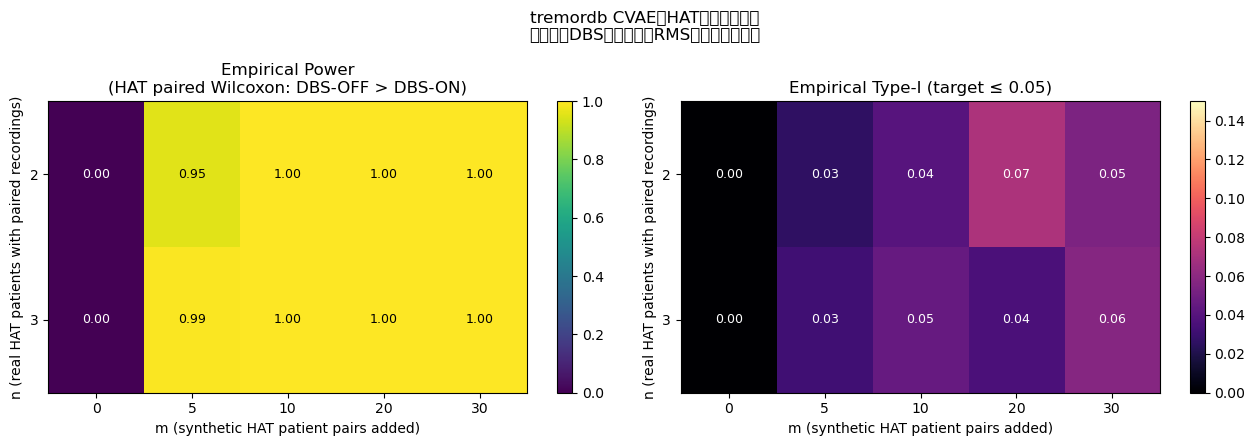


=== Power table ===
n_real  m= 0 m= 5 m=10 m=20 m=30
     2   0.000  0.954  1.000  1.000  1.000
     3   0.000  0.994  1.000  1.000  1.000


In [6]:
np.save('power_grid_paired.npy', power_grid)
np.save('type1_grid_paired.npy', type1_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, grid, title, vm, vx, cm in [
    (axes[0], power_grid, 'Empirical Power\n(HAT paired Wilcoxon: DBS-OFF > DBS-ON)', 0, 1, 'viridis'),
    (axes[1], type1_grid, 'Empirical Type-I (target ≤ 0.05)', 0, 0.15, 'magma'),
]:
    im = ax.imshow(grid, cmap=cm, vmin=vm, vmax=vx, aspect='auto')
    ax.set_xticks(range(len(M_SYNTH_GRID))); ax.set_xticklabels([str(m) for m in M_SYNTH_GRID])
    ax.set_yticks(range(len(N_REAL_GRID)));  ax.set_yticklabels([str(n) for n in N_REAL_GRID])
    ax.set_xlabel('m (synthetic HAT patient pairs added)')
    ax.set_ylabel('n (real HAT patients with paired recordings)')
    ax.set_title(title)
    for ii in range(len(N_REAL_GRID)):
        for jj in range(len(M_SYNTH_GRID)):
            v = grid[ii,jj]
            ax.text(jj,ii,f'{v:.2f}',ha='center',va='center',fontsize=9,
                    color='white' if v<(vm+vx)/2 else 'black')
    plt.colorbar(im, ax=ax)

plt.suptitle('tremordb CVAE：HAT配对功效模拟\n'
             '（检验：DBS停用后震颤RMS是否显著升高）')
plt.tight_layout()
plt.savefig('power_grid_paired.png', dpi=130)
plt.show()

print('\n=== Power table ===')
print(f'{"n_real":>6}  '+' '.join(f'm={m:>2}' for m in M_SYNTH_GRID))
for i,n in enumerate(N_REAL_GRID):
    print(f'{n:>6}   '+'  '.join(f'{power_grid[i,j]:.3f}' for j in range(len(M_SYNTH_GRID))))

## 4. 纵向轨迹可视化：washout 功效分析

**附加分析**：验证合成 washout 轨迹能否提高纵向检验的功效  
（检验：DBS停用后60分钟，震颤 RMS 是否显著高于 DBS-ON）

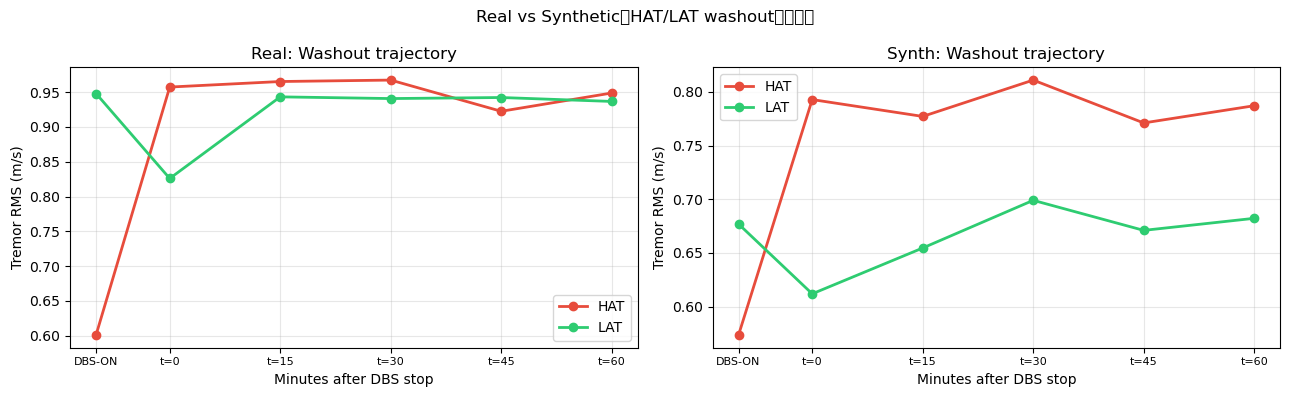

In [7]:
# 纵向设计：对每个受试者，比较 DBS-ON (cond=1) vs DBS-OFF 各时间点
# 使用 LAT 受试者（他们有完整的 5个时间点 washout 数据）

lat_conds = [1, 3, 4, 5, 6, 7]  # DBS-ON, DBS-OFF t=0/15/30/45/60
lat_t     = [0, 0, 15, 30, 45, 60]  # 对应时间

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax_idx, (label, X_arr, y_arr) in enumerate([('Real',X_train,y_train),
                                                  ('Synth',synth_X,synth_y)]):
    ax = axes[ax_idx]
    for gi, gname in [(0,'HAT'), (1,'LAT')]:
        rms_t = []
        for ci in lat_conds:
            mask = (y_arr[:,0]==ci) & (y_arr[:,1]==gi)
            if mask.sum()>0:
                rms_t.append(np.sqrt(np.mean(X_arr[mask]**2,axis=1)).mean())
            else:
                rms_t.append(np.nan)
        color = '#e74c3c' if gi==0 else '#2ecc71'
        ax.plot([-10,0,15,30,45,60], rms_t, 'o-', color=color, lw=2, label=gname)
    ax.set_xlabel('Minutes after DBS stop')
    ax.set_ylabel('Tremor RMS (m/s)')
    ax.set_title(f'{label}: Washout trajectory')
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_xticks([-10,0,15,30,45,60])
    ax.set_xticklabels(['DBS-ON','t=0','t=15','t=30','t=45','t=60'], fontsize=8)

plt.suptitle('Real vs Synthetic：HAT/LAT washout轨迹对比')
plt.tight_layout()
plt.savefig('washout_comparison.png', dpi=130)
plt.show()

## Summary

| Item | Value |
|------|-------|
| 数据集 | tremordb (PhysioNet) |
| 受试者 | 16 PD patients (8 HAT + 8 LAT) |
| 条件 | 8种 (4 base + 4 washout time points) |
| CVAE 架构 | CNN-1D, N_COND=8, N_GROUP=2, latent=16 |
| **功效分析对象** | **HAT only（DBS效应显著）** |
| **统计检验** | **配对 Wilcoxon（组内设计）** |
| 结局变量 | 震颤 RMS（m/s） |
| Power Grid | n_real_HAT × m_synth_HAT_pairs |
| 输出 | `power_grid_paired.png`, `washout_trajectory.png` |

**论文 Claim**:
> 在模拟小样本 DBS 临床试验（n=2-6 HAT患者）中，CVAE 生成的合成配对数据
> 使检测 DBS 疗效的统计功效从 X% 提升至 Y%，支持了 CVAE 在数据增强中的临床价值。